# Finding the P4 oscillators from the SCCs of the cycling subnetwork

In `00_analysis_boolean_core.ipynb` (October 2026 model), phenotype class **P4** holds eight
attractors in which `Proliferation` is fixed OFF (with `Cell_cycle` OFF and `Senescence` ON), while
`Apoptosis` and `Autop_digestion` oscillate. This notebook repeats on P4 the structural analysis
that `00_2_structural_scc_analysis.ipynb` ran on P7, the class in which all three readouts
oscillate. Can a single structural step on the network **of the nodes that actually cycle in P4**
find the oscillator directly?

That step is the **strongly connected component** (SCC): a maximal set of nodes in which every node
can reach every other. Every feedback loop lies entirely inside one SCC, and nodes outside SCCs
only relay signals. By Thomas' rule, a sustained oscillation needs a **negative** loop.

Steps:

1. Compute the eight P4 attractors.
2. Keep only the nodes that cycle, that is, take both values inside the attractor.
3. Build the subnetwork of those nodes from the signed interaction graph.
4. Decompose it into SCCs.
5. Identify the oscillator: the SCC whose loops are all negative, and that nothing else regulates.
6. Check whether the other SCC, if it has negative loops, can oscillate on its own.

In [1]:
import itertools
import os
import xml.etree.ElementTree as ET
import zipfile
from pathlib import Path

import biobalm
import biodivine_aeon as ba
import networkx as nx
import pandas as pd
import pygraphviz as pgv
from IPython.display import Image

if not Path("model").exists():          # repo root, as in 00_analysis_boolean_core.ipynb
    os.chdir("../../../../")
pd.set_option("display.max_colwidth", None)

BNET_PATH = Path("model/autophagy_october26/Autophagy_and_apoptosis_Sept26_2026-10-01.bnet")
READOUTS = ["Proliferation", "Autop_digestion", "Apoptosis"]

## 1 — The P4 attractors

P4 = the minimal trap spaces with `Proliferation = 0` and both `Apoptosis` and `Autop_digestion`
free. No other phenotype class of `00_analysis_boolean_core.ipynb` has this pattern: P1–P3, P5 and
P6 fix `Apoptosis = 1`, P7 leaves `Proliferation` free, and P8 fixes `Apoptosis = 0`. Class numbers
come from a frequency ranking that can reorder between model revisions, so the class is selected by
this pattern and not by its number. `biobalm` gives one seed state per attractor. The attractor is
the set of states reachable from that seed under asynchronous updating, and AEON computes that set
symbolically. The table shows only the inputs that differ between the eight attractors.

In [2]:
sd = biobalm.SuccessionDiagram.from_file(str(BNET_PATH))
sd.build()
names = sd.network.variable_names()
INPUTS = ["AA_Starvation", "Growth_factor", "TNF_R_or_DR", "O_stress", "Glucose_starv", "Insuline"]

p4 = [n for n in sd.minimal_trap_spaces()
      if sd.node_data(n)["space"].get("Proliferation") == 0
      and not any(r in sd.node_data(n)["space"] for r in ["Apoptosis", "Autop_digestion"])]
assert len(p4) == 8

graph = ba.AsynchronousGraph(sd.network)
attractors = {f"P4.{k + 1}": ba.Reachability.reach_fwd(
                  graph, graph.mk_subspace(sd.node_attractor_seeds(n, compute=True)[0]))
              for k, n in enumerate(p4)}
spaces = {f"P4.{k + 1}": sd.node_data(n)["space"] for k, n in enumerate(p4)}

# Show only the inputs that differ between the P4 attractors
varying = [i for i in INPUTS if len({spaces[k].get(i, "*") for k in spaces}) > 1]
pd.DataFrame({k: {**{i: spaces[k].get(i, "*") for i in varying},
                  "attractor states": f"{att.cardinality():.1e}"} for k, att in attractors.items()}).T

,Growth_factor,TNF_R_or_DR,Insuline,attractor states
P4.1,0,1,0,6.4e+13
P4.2,0,1,1,1.3e+14
P4.3,1,1,0,1.6e+16
P4.4,1,1,1,3.3e+16
P4.5,0,0,0,1.0e+15
P4.6,0,0,1,2.0e+15
P4.7,1,0,0,2.6e+17
P4.8,1,0,1,5.2e+17


## 2 — Keep only the cycling nodes

A node **cycles** if the attractor contains states with the node OFF and states with it ON.
Every other node is fixed inside the attractor and acts as a constant.

In [3]:
def cycling_nodes(att):
    return [v for v in names
            if not att.intersect(graph.mk_subspace({v: 0})).is_empty()
            and not att.intersect(graph.mk_subspace({v: 1})).is_empty()]

cycling = {k: cycling_nodes(att) for k, att in attractors.items()}

# Each cycling set equals the free nodes of the minimal trap space
assert all(set(cycling[k]) == set(names) - set(spaces[k]) for k in cycling)
pd.Series({k: len(v) for k, v in cycling.items()}, name="cycling nodes").to_frame().T

,P4.1,P4.2,P4.3,P4.4,P4.5,P4.6,P4.7,P4.8
cycling nodes,46,47,54,55,50,51,58,59


In every attractor, the cycling nodes are exactly the free nodes of its trap space: no free node
stays stuck inside the attractor.

## 3 — The cycling subnetwork

Take the signed interaction graph of the full model: one edge per regulation, with sign `+`
(activation) or `-` (inhibition) inferred from the rules. Keep only the cycling nodes and the edges
between them, and drop all fixed nodes with their edges.

In [4]:
def signed_graph(bn):
    g = nx.DiGraph()
    g.add_nodes_from(bn.variable_names())
    for r in bn.regulations():
        g.add_edge(bn.get_variable_name(r["source"]), bn.get_variable_name(r["target"]),
                   sign=str(r["sign"]))
    return g

full = signed_graph(ba.BooleanNetwork.from_file(str(BNET_PATH)).infer_valid_graph())
sub = {k: full.subgraph(v).copy() for k, v in cycling.items()}

pd.DataFrame({k: {"nodes": g.number_of_nodes(), "edges": g.number_of_edges()}
              for k, g in [("full model", full)] + list(sub.items())}).T

,nodes,edges
full model,125,216
P4.1,46,65
P4.2,47,66
P4.3,54,80
P4.4,55,81
P4.5,50,69
P4.6,51,70
P4.7,58,84
P4.8,59,85


An edge between two cycling nodes may still have no effect when a fixed node switches its
regulator off. For example, `B = A & C` with `C` fixed at 0. To check this, fix the trap space
values in the rules and let AEON drop the edges that no longer have any effect. The edge sets
match exactly, so every edge kept above is functional inside the attractor.

In [5]:
def percolated_graph(space):
    bn = ba.BooleanNetwork.from_file(str(BNET_PATH))
    for name, value in space.items():
        bn.set_update_function(name, "true" if value else "false")
    return signed_graph(bn.inline_constants(infer_constants=True, repair_graph=True))

assert all(set(sub[k].edges) == set(percolated_graph(spaces[k]).edges) for k in sub)

### The cycling nodes in the whole model

The whole interaction graph, drawn twice: once with the node positions saved in the GINsim file
(`.zginml`), once with a hierarchical (graphviz `dot`) layout. Colour code:

* **dark purple**: cycling in all eight P4 attractors;
* **light purple**: cycling in only some of them (listed by the print below);
* **faded**: fixed in every P4 attractor.

An edge is coloured (green = activation, red = inhibition) when both of its ends cycle, and faded
otherwise.

cycling in some attractors only: {'P4.1': [], 'P4.2': ['IRS1'], 'P4.3': ['BBC3', 'BCL2_BECN1_C', 'H2O2', 'MAP2K1', 'SP1', 'SP1_sustained', 'mRNA_BBC3', 'mRNA_SP1'], 'P4.4': ['BBC3', 'BCL2_BECN1_C', 'H2O2', 'IRS1', 'MAP2K1', 'SP1', 'SP1_sustained', 'mRNA_BBC3', 'mRNA_SP1'], 'P4.5': ['FLIP', 'IKBKB', 'NFKBIA', 'NFkappaB'], 'P4.6': ['FLIP', 'IKBKB', 'IRS1', 'NFKBIA', 'NFkappaB'], 'P4.7': ['BBC3', 'BCL2_BECN1_C', 'FLIP', 'H2O2', 'IKBKB', 'MAP2K1', 'NFKBIA', 'NFkappaB', 'SP1', 'SP1_sustained', 'mRNA_BBC3', 'mRNA_SP1'], 'P4.8': ['BBC3', 'BCL2_BECN1_C', 'FLIP', 'H2O2', 'IKBKB', 'IRS1', 'MAP2K1', 'NFKBIA', 'NFkappaB', 'SP1', 'SP1_sustained', 'mRNA_BBC3', 'mRNA_SP1']}


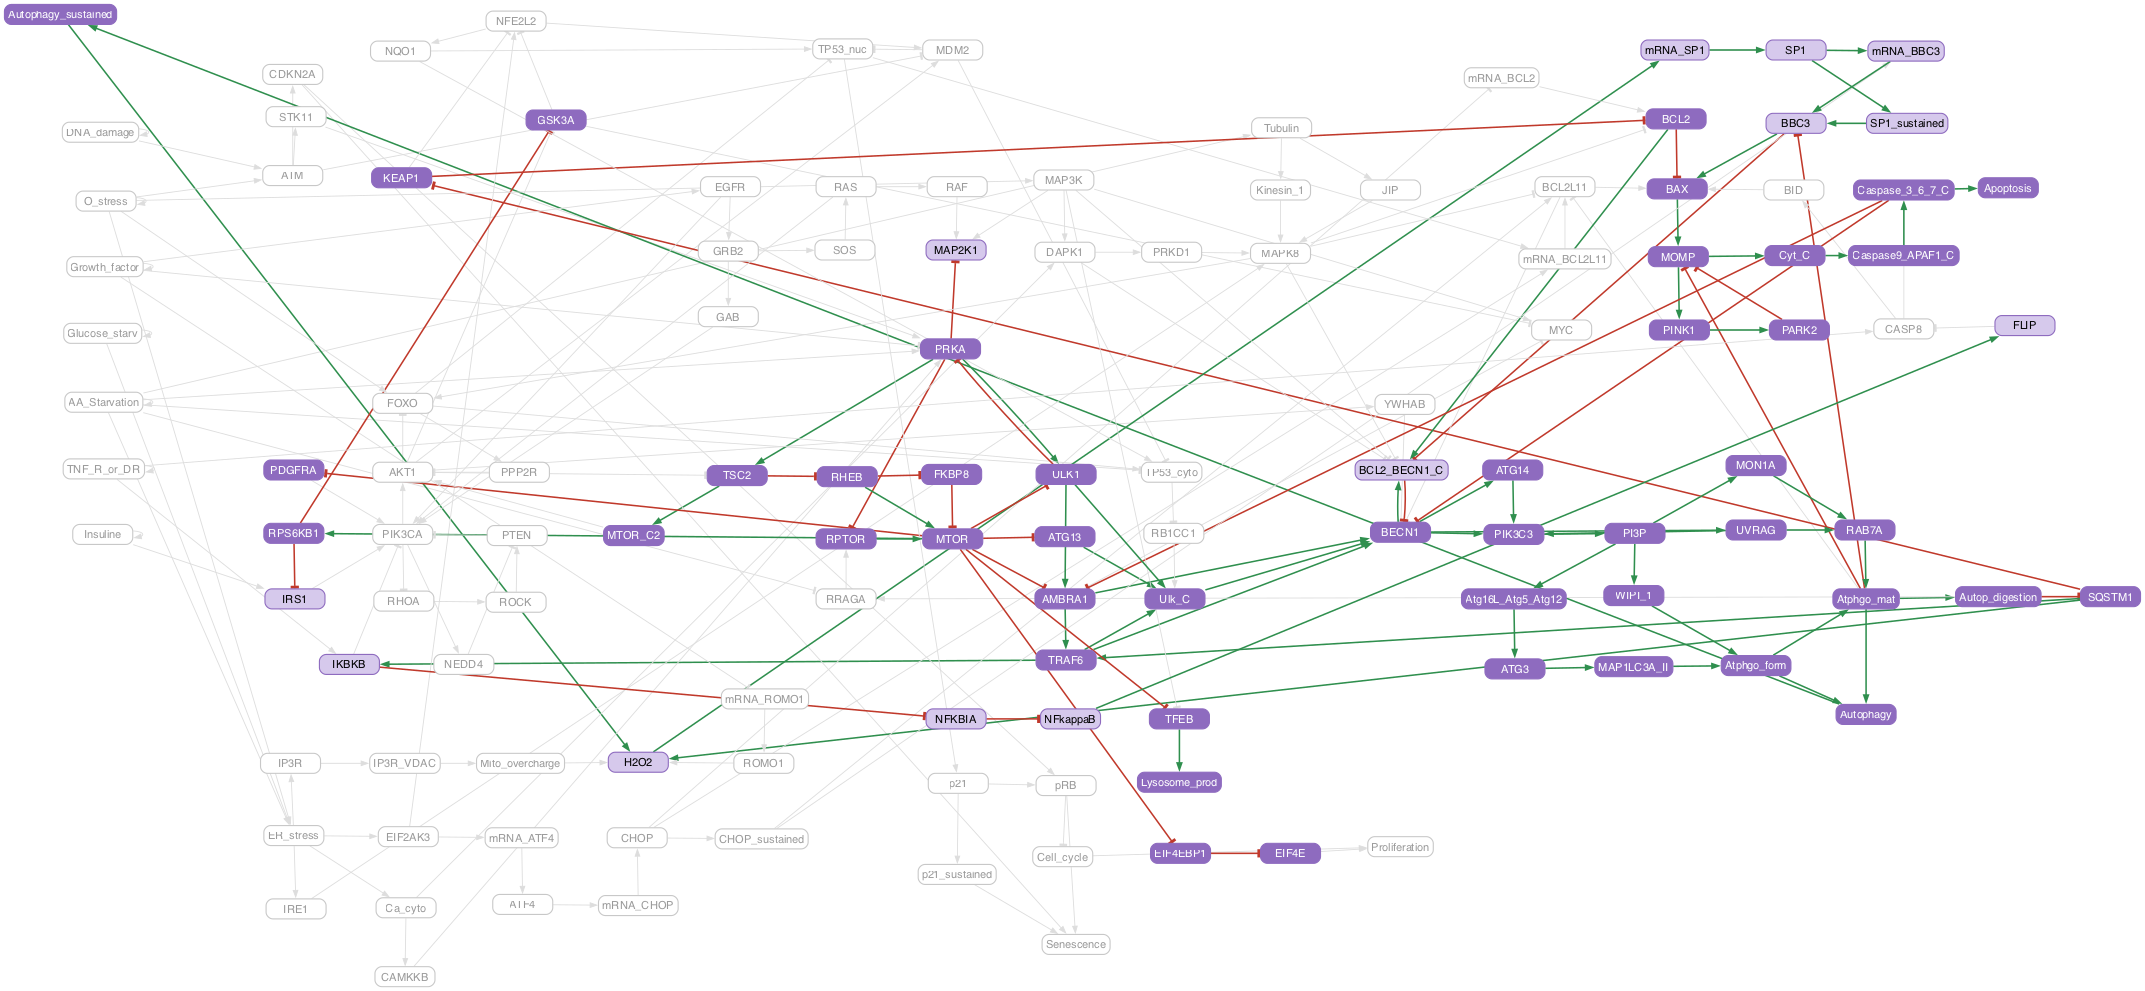

In [6]:
ZGINML_PATH = Path("model/autophagy_october26/Autophagy_and_apoptosis_Sept26_2026-10-01.zginml")

with zipfile.ZipFile(ZGINML_PATH) as z:
    root = ET.fromstring(z.read("GINsim-data/regulatoryGraph.ginml"))
ginsim_pos = {n.get("id"): (float(v.get("x")), float(v.get("y")))
              for n in root.iter("node") for v in n.iter("nodevisualsetting")}
assert set(ginsim_pos) == set(full)

cycling_all = set.intersection(*map(set, cycling.values()))
cycling_any = set.union(*map(set, cycling.values()))
print("cycling in some attractors only:", {k: sorted(set(v) - cycling_all) for k, v in cycling.items()})
NODE_STYLE = {"all": dict(fillcolor="#8e6bbf", color="#8e6bbf", fontcolor="white"),
              "some": dict(fillcolor="#d6c9ec", color="#8e6bbf", fontcolor="black"),
              "fixed": dict(fillcolor="white", color="#c8c8c8", fontcolor="#9a9a9a")}

def draw_full_network(layout):
    A = pgv.AGraph(directed=True, rankdir="TB", nodesep="0.12", ranksep="0.3", outputorder="edgesfirst")
    A.node_attr.update(shape="box", style="rounded,filled", fontname="Helvetica", fontsize="10",
                       height="0.25", margin="0.05,0.02")
    for v in full:
        kind = "all" if v in cycling_all else "some" if v in cycling_any else "fixed"
        attrs = dict(NODE_STYLE[kind])
        if layout == "ginsim":                      # GINsim y axis points down, graphviz y points up
            x, y = ginsim_pos[v]
            attrs["pos"] = f"{0.9 * x:.0f},{-0.9 * y:.0f}!"
        A.add_node(v, **attrs)
    for a, b in full.edges:
        positive = full[a][b]["sign"] == "+"
        cycles = a in cycling_any and b in cycling_any
        A.add_edge(a, b, color=("#2f8f4e" if positive else "#c0392b") if cycles else "#dddddd",
                   penwidth="1.4" if cycles else "0.8", arrowhead="normal" if positive else "tee",
                   arrowsize="0.6")
    if layout == "ginsim":                          # keep the saved positions, straight edges
        return Image(A.draw(format="png", prog="neato", args="-n2 -Gsplines=line -Gdpi=80"))
    return Image(A.draw(format="png", prog="dot", args="-Gdpi=80"))

draw_full_network("ginsim")

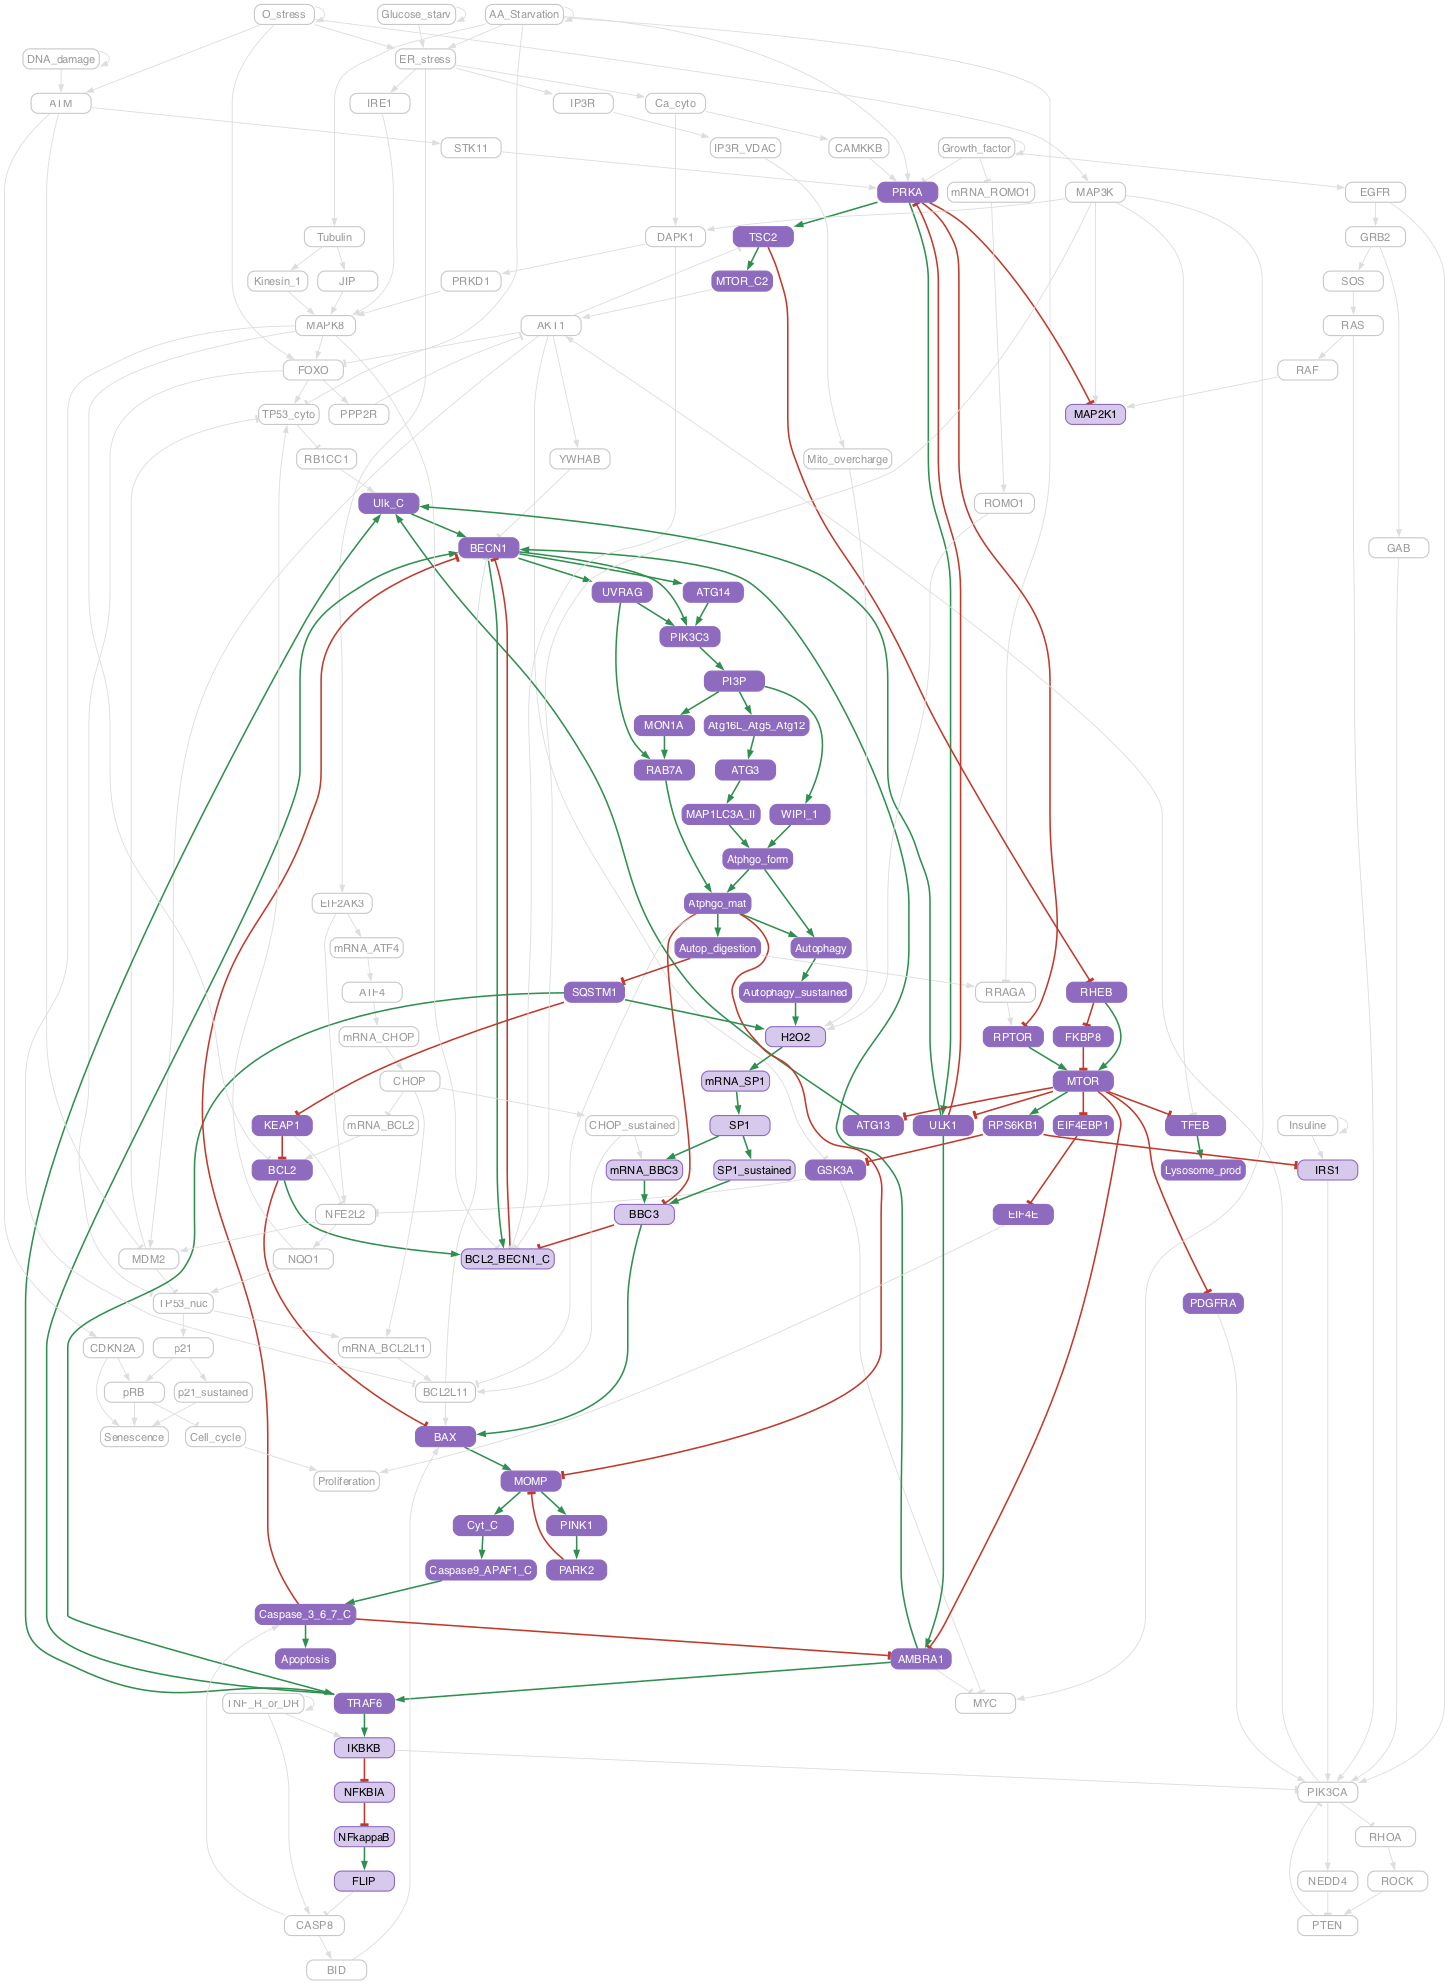

In [7]:
draw_full_network("hierarchical")

> **TODO (P4):** describe which modules cycle and which are fixed in P4, after running. For comparison,
> in P7 the cycling block was AMPK–MTOR–ULK1 + mTORC1 targets, the autophagy cascade, the p62 branch
> `SQSTM1 ⊣ KEAP1 ⊣ BCL2 ⊣ BAX → MOMP` and the readouts, while ER stress/UPR, PI3K/AKT, p53, NRF2, RAS and
> `MAPK8` were fixed. Since `Proliferation` is OFF in P4, check which part of the route to it is fixed.

### The cycling subnetwork on its own

The P4.1 cycling subnetwork with the hierarchical layout, before any SCC analysis. The other
attractors differ from it at most by the light-purple nodes above.

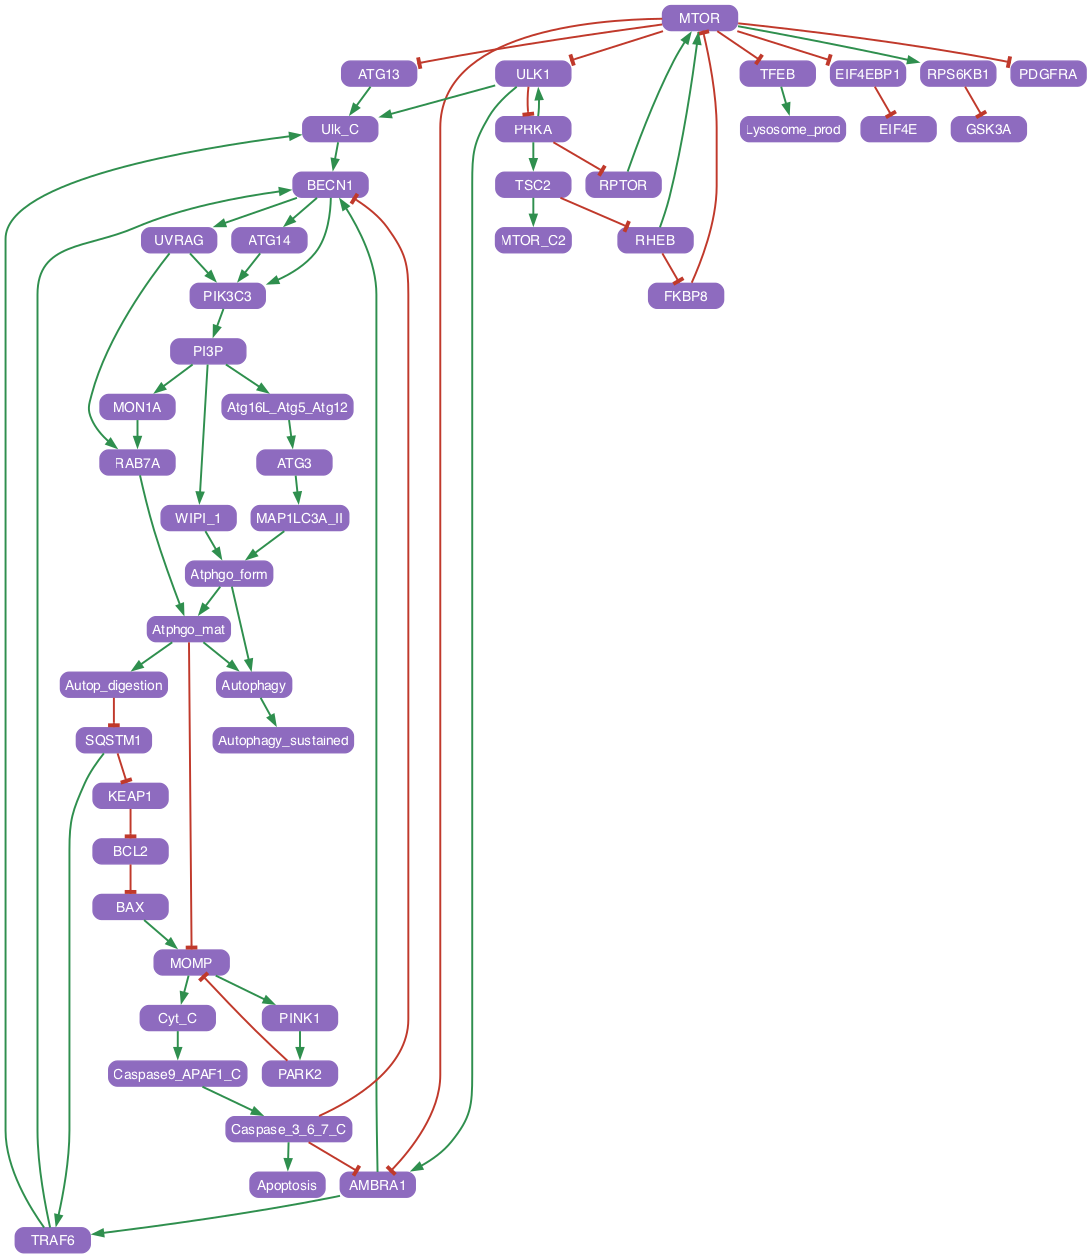

In [8]:
A = pgv.AGraph(directed=True, rankdir="TB", nodesep="0.15", ranksep="0.3")
A.node_attr.update(shape="box", style="rounded,filled", fontname="Helvetica", fontsize="10",
                   height="0.25", margin="0.05,0.02", **NODE_STYLE["all"])
for a, b in sub["P4.1"].edges:
    positive = sub["P4.1"][a][b]["sign"] == "+"
    A.add_edge(a, b, color="#2f8f4e" if positive else "#c0392b", penwidth="1.4",
               arrowhead="normal" if positive else "tee", arrowsize="0.7")
Image(A.draw(format="png", prog="dot", args="-Gdpi=100"))

## 4 — SCCs of the cycling subnetwork

List every non-trivial SCC (more than one node, or a self-loop), its feedback loops, and how many
of them are negative (odd number of inhibitions).

In [9]:
def loop_sign(g, loop):
    return "-" if sum(g[a][b]["sign"] == "-" for a, b in zip(loop, loop[1:] + loop[:1])) % 2 else "+"

def nontrivial_sccs(g):
    return sorted((s for s in nx.strongly_connected_components(g)
                   if len(s) > 1 or g.has_edge(*[next(iter(s))] * 2)), key=len)

def scc_table(g):
    rows = []
    for s in nontrivial_sccs(g):
        loops = list(nx.simple_cycles(g.subgraph(s)))
        rows.append({"nodes": len(s), "loops": len(loops),
                     "negative loops": sum(loop_sign(g, c) == "-" for c in loops),
                     "members": ", ".join(sorted(s))})
    return pd.DataFrame(rows)

pd.concat({k: scc_table(g) for k, g in sub.items()}, names=["attractor", "SCC"])

nodes  loops  negative loops  \
attractor SCC                                 
P4.1      0        7      4               4   
          1       27    101              61   
P4.2      0        7      4               4   
          1       27    101              61   
P4.3      0        7      4               4   
          1       36    422             220   
P4.4      0        7      4               4   
          1       36    422             220   
P4.5      0        7      4               4   
          1       27    101              61   
P4.6      0        7      4               4   
          1       27    101              61   
P4.7      0        7      4               4   
          1       36    422             220   
P4.8      0        7      4               4   
          1       36    422             220   

                                                                                                                                                                                                                                                                                                                                                                members  
attractor SCC                                                                                                                                                                                                                                                                                                                                                            
P4.1      0                                                                                                                                                                                                                                                                                                                  FKBP8, MTOR, PRKA, RHEB, RPTOR, TSC2, ULK1  
          1                                                                                                       AMBRA1, ATG14, ATG3, Atg16L_Atg5_Atg12, Atphgo_form, Atphgo_mat, Autop_digestion, BAX, BCL2, BECN1, Caspase9_APAF1_C, Caspase_3_6_7_C, Cyt_C, KEAP1, MAP1LC3A_II, MOMP, MON1A, PARK2, PI3P, PIK3C3, PINK1, RAB7A, SQSTM1, TRAF6, UVRAG, Ulk_C, WIPI_1  
P4.2      0                                                                                                                                                                                                                                                                                                                  FKBP8, MTOR, PRKA, RHEB, RPTOR, TSC2, ULK1  
          1                                                                                                       AMBRA1, ATG14, ATG3, Atg16L_Atg5_Atg12, Atphgo_form, Atphgo_mat, Autop_digestion, BAX, BCL2, BECN1, Caspase9_APAF1_C, Caspase_3_6_7_C, Cyt_C, KEAP1, MAP1LC3A_II, MOMP, MON1A, PARK2, PI3P, PIK3C3, PINK1, RAB7A, SQSTM1, TRAF6, UVRAG, Ulk_C, WIPI_1  
P4.3      0                                                                                                                                                                                                                                                                                                                  FKBP8, MTOR, PRKA, RHEB, RPTOR, TSC2, ULK1  
          1    AMBRA1, ATG14, ATG3, Atg16L_Atg5_Atg12, Atphgo_form, Atphgo_mat, Autop_digestion, Autophagy, Autophagy_sustained, BAX, BBC3, BCL2, BCL2_BECN1_C, BECN1, Caspase9_APAF1_C, Caspase_3_6_7_C, Cyt_C, H2O2, KEAP1, MAP1LC3A_II, MOMP, MON1A, PARK2, PI3P, PIK3C3, PINK1, RAB7A, SP1, SP1_sustained, SQSTM1, TRAF6, UVRAG, Ulk_C, WIPI_1, mRNA_BBC3, mRNA_SP1  
P4.4      0                                                                                                                                                                                                                                                                     

> **TODO (P4):** describe the SCCs from the table above. For comparison, P7 gave the same two SCCs in all
> four attractors: a 7-node SCC whose 4 loops are all negative (`PRKA, ULK1, MTOR, RPTOR, TSC2, RHEB,
> FKBP8`), and a 27-node autophagy/apoptosis crosstalk SCC with 61 negative loops out of 101.
> The code below takes the SCC containing `PRKA` as the oscillator candidate and the largest other SCC
> as the crosstalk SCC. If P4 gives more than two SCCs, or `PRKA` is on no loop, revise sections 5–6.

## 5 — Is the `PRKA` SCC still the oscillator?

Two checks on P4.1: which negative loops each SCC holds, and how the SCCs are connected. Only
negative loops of at most 9 nodes are listed.

In [10]:
def loop_string(g, loop):
    start = next((h for h in ["PRKA", "MOMP", "Autop_digestion", "BECN1", "PIK3C3"] if h in loop), min(loop))
    i = loop.index(start)
    path = loop[i:] + loop[:i] + [start]
    return path[0] + "".join((" → " if g[a][b]["sign"] == "+" else " ⊣ ") + b
                             for a, b in zip(path, path[1:]))

g = sub["P4.1"]
sccs = nontrivial_sccs(g)
oscillator = next(s for s in sccs if "PRKA" in s)
crosstalk = max((s for s in sccs if s is not oscillator), key=len)
scc_name = {id(oscillator): f"{len(oscillator)}-node", id(crosstalk): f"{len(crosstalk)}-node"}
negative = {id(s): [c for c in nx.simple_cycles(g.subgraph(s)) if loop_sign(g, c) == "-"]
            for s in (oscillator, crosstalk)}
pd.DataFrame([{"SCC": scc_name[id(s)], "length": len(c), "loop": loop_string(g, c)}
              for s in (oscillator, crosstalk) for c in negative[id(s)] if len(c) <= 9]
             ).sort_values(["SCC", "length"], ignore_index=True)

,SCC,length,loop
0,27-node,3,MOMP → PINK1 → PARK2 ⊣ MOMP
1,27-node,7,Autop_digestion ⊣ SQSTM1 → TRAF6 → BECN1 → UVRAG → RAB7A → Atphgo_mat → Autop_digestion
2,27-node,8,Autop_digestion ⊣ SQSTM1 → TRAF6 → Ulk_C → BECN1 → UVRAG → RAB7A → Atphgo_mat → Autop_digestion
3,27-node,9,Autop_digestion ⊣ SQSTM1 → TRAF6 → BECN1 → PIK3C3 → PI3P → MON1A → RAB7A → Atphgo_mat → Autop_digestion
4,27-node,9,Autop_digestion ⊣ SQSTM1 → TRAF6 → BECN1 → PIK3C3 → PI3P → WIPI_1 → Atphgo_form → Atphgo_mat → Autop_digestion
5,7-node,2,PRKA → ULK1 ⊣ PRKA
6,7-node,4,PRKA ⊣ RPTOR → MTOR ⊣ ULK1 ⊣ PRKA
7,7-node,5,PRKA → TSC2 ⊣ RHEB → MTOR ⊣ ULK1 ⊣ PRKA
8,7-node,6,PRKA → TSC2 ⊣ RHEB ⊣ FKBP8 ⊣ MTOR ⊣ ULK1 ⊣ PRKA


In [11]:
print("edges into the 7-node SCC from other cycling nodes:",
      [(a, b) for a, b in g.in_edges(oscillator) if a not in oscillator])
print(f"7-node SCC reaches the {len(crosstalk)}-node SCC:", nx.has_path(g, "PRKA", "BECN1"))
print("readouts downstream of the 7-node SCC:", [r for r in READOUTS if r in nx.descendants(g, "PRKA")])

edges into the 7-node SCC from other cycling nodes: []
7-node SCC reaches the 27-node SCC: True
readouts downstream of the 7-node SCC: ['Autop_digestion', 'Apoptosis']


> **TODO (P4):** interpret the two checks above. For comparison, in P7 the 7-node SCC held the four
> negative loops through `PRKA`, received no edge from any other cycling node (it was the source), and
> drove the crosstalk SCC and all three readouts.

The table below counts, for each inhibition inside the crosstalk SCC, how many of its negative loops
pass through it.

In [12]:
def loop_edges(loop):
    return set(zip(loop, loop[1:] + loop[:1]))

pd.DataFrame([{"inhibition": f"{a} ⊣ {b}",
               "negative loops through it": sum((a, b) in loop_edges(c) for c in negative[id(crosstalk)])}
              for a, b in g.subgraph(crosstalk).edges if g[a][b]["sign"] == "-"]
             ).sort_values("negative loops through it", ascending=False, ignore_index=True)

,inhibition,negative loops through it
0,Autop_digestion ⊣ SQSTM1,60
1,SQSTM1 ⊣ KEAP1,40
2,BCL2 ⊣ BAX,40
3,KEAP1 ⊣ BCL2,40
4,Caspase_3_6_7_C ⊣ AMBRA1,30
5,Caspase_3_6_7_C ⊣ BECN1,10
6,PARK2 ⊣ MOMP,1
7,Atphgo_mat ⊣ MOMP,0


> **TODO (P4):** interpret the table above. For comparison, in P7, 60 of the 61 negative loops of the
> crosstalk SCC passed through `Autop_digestion ⊣ SQSTM1` (p62 degradation), and closed back on autophagy
> via `SQSTM1 → TRAF6 → BECN1 / Ulk_C` and on apoptosis via `SQSTM1 ⊣ KEAP1 ⊣ BCL2 ⊣ BAX → MOMP`; the
> last one was mitophagy (`MOMP → PINK1 → PARK2 ⊣ MOMP`).

A negative loop is necessary for an oscillation but not sufficient, so the structure alone cannot say
whether the crosstalk SCC can oscillate without the `PRKA` SCC. Section 6 tests that on the dynamics.

### Why the cycling subset is needed

In the full interaction graph the `PRKA` SCC is part of a much larger SCC. These are the edges
that enter it from outside, and whether their source cycles in P4.1:

In [13]:
print("SCC of PRKA in the full graph:",
      len(next(s for s in nx.strongly_connected_components(full) if "PRKA" in s)), "nodes")
pd.DataFrame([{"edge": f"{a} {'→' if full[a][b]['sign'] == '+' else '⊣'} {b}",
               "source in P4.1": "cycling" if a in g else f"fixed = {spaces['P4.1'][a]}"}
              for a, b in full.in_edges(oscillator) if a not in oscillator])

SCC of PRKA in the full graph: 73 nodes


,edge,source in P4.1
0,AA_Starvation → PRKA,fixed = 0
1,CAMKKB → PRKA,fixed = 0
2,Growth_factor ⊣ PRKA,fixed = 0
3,STK11 → PRKA,fixed = 1
4,RRAGA → RPTOR,fixed = 1
5,AKT1 ⊣ TSC2,fixed = 0


If every feedback into the oscillator comes from a node that is fixed inside P4, removing the fixed
nodes cuts those edges, and the oscillator becomes an SCC of its own.

Below, the P4.1 cycling subnetwork is coloured by SCC (flat arrowhead = inhibition, square = readout).

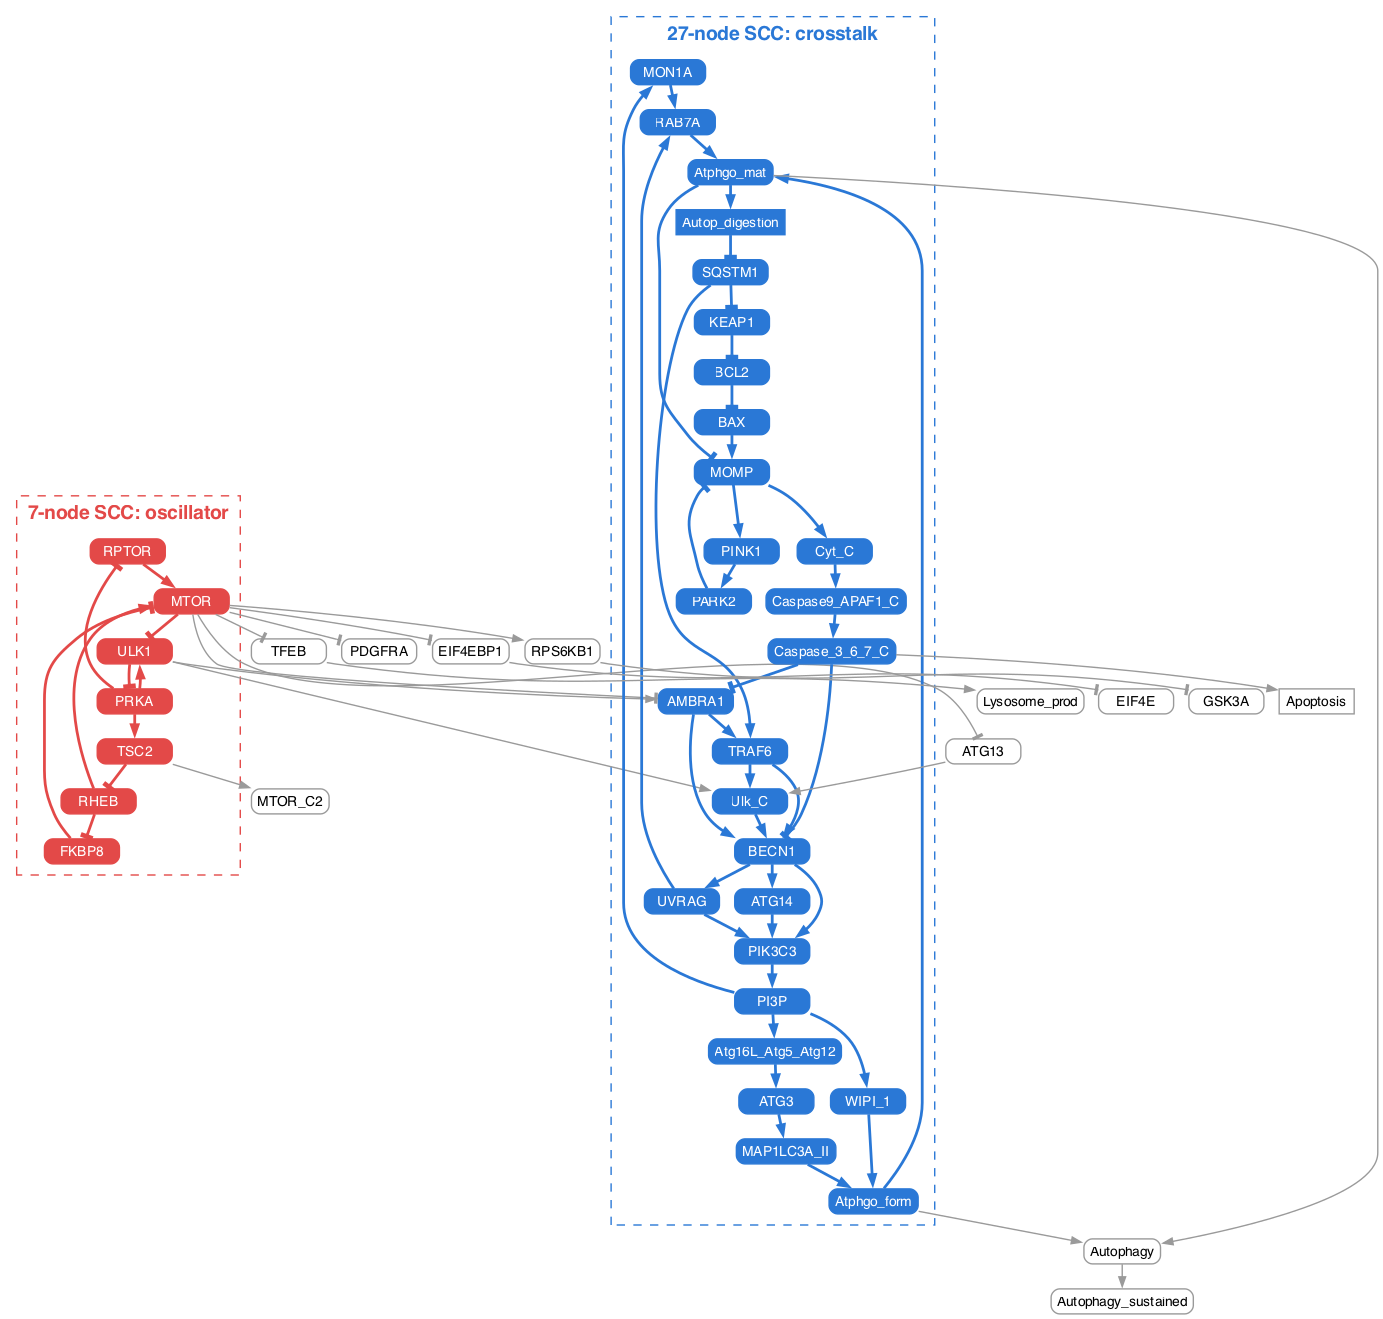

In [14]:
COLOR = {"oscillator": "#e34948", "crosstalk": "#2a78d6", "feedforward": "#9a9a9a"}
group = {v: "oscillator" if v in oscillator else "crosstalk" if v in crosstalk else "feedforward" for v in g}

A = pgv.AGraph(directed=True, rankdir="TB", nodesep="0.15", ranksep="0.25")
A.node_attr.update(shape="box", style="rounded,filled", fontname="Helvetica", fontsize="10",
                   height="0.25", margin="0.06,0.02")
for v in g:
    ff = group[v] == "feedforward"
    A.add_node(v, fillcolor="white" if ff else COLOR[group[v]], color=COLOR[group[v]],
               fontcolor="black" if ff else "white", style="filled" if v in READOUTS else "rounded,filled")
for a, b in g.edges:
    same = group[a] == group[b] != "feedforward"
    A.add_edge(a, b, color=COLOR[group[a]] if same else "#9a9a9a", penwidth="2" if same else "1",
               arrowhead="normal" if g[a][b]["sign"] == "+" else "tee", arrowsize="0.7")
for name, label in [("oscillator", f"{len(oscillator)}-node SCC: oscillator"),
                    ("crosstalk", f"{len(crosstalk)}-node SCC: crosstalk")]:
    A.add_subgraph([v for v in g if group[v] == name], name=f"cluster_{name}", label=label,
                   style="dashed", color=COLOR[name], fontcolor=COLOR[name], fontname="Helvetica-Bold")
Image(A.draw(format="png", prog="dot", args="-Gdpi=100"))

## 6 — Can the crosstalk SCC oscillate without the oscillator?

Freeze the oscillator nodes at each value combination that the attractor visits. Keep the trap
space values fixed as well, and compute the attractors of what remains with AEON. If no node cycles,
the crosstalk SCC only follows the oscillator. If nodes still cycle, the crosstalk SCC sustains an
oscillation of its own.

This took about 30 s per attractor on P7; P4 has eight attractors.

In [15]:
OSC = sorted(oscillator)

def cycling_when_frozen(space, values):
    # Nodes that still cycle in some attractor once `space` and `values` are held constant
    bn = ba.BooleanNetwork.from_file(str(BNET_PATH))
    for name, value in {**space, **values}.items():
        bn.set_update_function(name, "true" if value else "false")
    bn = bn.inline_constants(infer_constants=True, repair_graph=True)
    if bn.variable_count() == 0:
        return set()
    frozen = ba.AsynchronousGraph(bn)
    return {v for att in ba.Attractors.attractors(frozen) for v in bn.variable_names()
            if not att.intersect(frozen.mk_subspace({v: 0})).is_empty()
            and not att.intersect(frozen.mk_subspace({v: 1})).is_empty()}

frozen_runs = []
for k, att in attractors.items():
    for values in itertools.product([0, 1], repeat=len(OSC)):
        state = dict(zip(OSC, values))
        if att.intersect(graph.mk_subspace(state)).is_empty():
            continue                                # oscillator state never visited in this attractor
        frozen_runs.append({"attractor": k, **state, "still cycling": cycling_when_frozen(spaces[k], state)})
frozen_runs = pd.DataFrame(frozen_runs)

(frozen_runs.assign(**{"crosstalk cycles": frozen_runs["still cycling"].map(bool)})
 .groupby(["attractor", "ULK1", "MTOR"])["crosstalk cycles"].agg(["sum", "count"])
 .rename(columns={"sum": "states where it cycles", "count": "oscillator states visited"}))

states where it cycles  oscillator states visited
attractor ULK1 MTOR                                                   
P7.1      0    0                          0                         32
               1                          0                         30
          1    0                         32                         32
               1                          0                         22
P7.2      0    0                          0                         32
               1                          0                         30
          1    0                         32                         32
               1                          0                         22
P7.3      0    0                          0                         32
               1                          0                         30
          1    0                         32                         32
               1                          0                         22
P7.4      0    0                          0                         32
               1                          0                         30
          1    0                         32                         32
               1                          0                         22

In [16]:
# Within one attractor, every frozen state that still cycles keeps the same set of nodes cycling
still = frozen_runs.groupby("attractor")["still cycling"].agg(lambda runs: set.union(*runs))
assert all(s in (set(), still[k]) for k, s in frozen_runs[["attractor", "still cycling"]].to_numpy())

pd.DataFrame({"nodes still cycling": still.map(len),
              "whole crosstalk SCC": still.map(lambda s: crosstalk <= s),
              "outside the crosstalk SCC": still.map(lambda s: ", ".join(sorted(s - crosstalk))),
              "readouts": still.map(lambda s: ", ".join(r for r in READOUTS if r in s))})

,nodes still cycling,whole crosstalk SCC,outside the crosstalk SCC,readouts
attractor,,,,
P7.1,30,True,"Apoptosis, Autophagy, Autophagy_sustained","Autop_digestion, Apoptosis"
P7.2,30,True,"Apoptosis, Autophagy, Autophagy_sustained","Autop_digestion, Apoptosis"
P7.3,34,True,"Apoptosis, Autophagy, Autophagy_sustained, FLIP, IKBKB, NFKBIA, NFkappaB","Autop_digestion, Apoptosis"
P7.4,34,True,"Apoptosis, Autophagy, Autophagy_sustained, FLIP, IKBKB, NFKBIA, NFkappaB","Autop_digestion, Apoptosis"


> **TODO (P4):** interpret the two tables above. For comparison, in P7 the crosstalk SCC kept cycling on
> its own only when the oscillator sat at `ULK1 = 1, MTOR = 0`, taking `Apoptosis` and
> `Autophagy`/`Autophagy_sustained` with it, so P7 held two coupled oscillators in a hierarchy: the
> AMPK–ULK1–MTOR oscillator gating the p62 autophagy/apoptosis oscillator.

## Summary

> **TODO (P4):** write after running. Points to cover, mirroring the P7 notebook:
>
> * number of cycling nodes per attractor, and whether they match the free nodes of the trap space
>   (asserted in section 2) and every edge between them is functional (asserted in section 3);
> * the SCC decomposition and whether it is the same in all eight attractors;
> * whether the `PRKA` SCC is still a source SCC of purely negative loops;
> * which inhibitions carry the crosstalk SCC's negative loops;
> * in which oscillator states the crosstalk SCC cycles on its own (section 6);
> * how this explains `Proliferation` being OFF while `Apoptosis` and `Autop_digestion` oscillate.